<a href="https://colab.research.google.com/github/bautistacoyotecatl1-svg/Modulo-2-Modelos-Estadisticos/blob/main/03_Estadistica_inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estadística inferencial

## Estimación puntual, propiedades de estimadores e intervalos de confianza

**Bautista Coyotecatl Gerardo**


Este cuaderno conecta los modelos probabilísticos con la inferencia estadística mediante teoría, cálculos manuales, implementación reproducible y simulación. El énfasis está en estimación; las pruebas de hipótesis quedan fuera del alcance.


## Tabla de contenidos

1. [Introducción y objetivos](#1-introducción-y-objetivos)
2. [De la probabilidad a la inferencia](#2-de-la-probabilidad-a-la-inferencia)
3. [Población, muestra, parámetro y estadístico](#3-población-muestra-parámetro-y-estadístico)
4. [Estimador, estimación y distribución muestral](#4-estimador-estimación-y-distribución-muestral)
5. [Error estándar y propiedades de estimadores](#5-error-estándar-y-propiedades-de-estimadores)
6. [Método de momentos](#6-método-de-momentos)
7. [Máxima verosimilitud](#7-máxima-verosimilitud)
8. [Distribuciones chi-cuadrada, t y F](#8-distribuciones-chi-cuadrada-t-y-f)
9. [Estimación por intervalos](#9-estimación-por-intervalos)
10. [Efectos de \(n\) y del nivel de confianza](#10-efectos-de-n-y-del-nivel-de-confianza)
11. [Simulación de cobertura](#11-simulación-de-cobertura)
12. [Laboratorio integrador](#12-laboratorio-integrador)
13. [Conclusiones](#13-conclusiones)
14. [Bibliografía](#14-bibliografía)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(123)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

def ic_media_sigma_conocida(x_barra, sigma, n, confianza=0.95):
    alpha = 1 - confianza
    z = stats.norm.ppf(1 - alpha / 2)
    margen = z * sigma / np.sqrt(n)
    return x_barra - margen, x_barra + margen

def ic_media_sigma_desconocida(datos, confianza=0.95):
    datos = np.asarray(datos)
    n = datos.size
    x_barra = datos.mean()
    s = datos.std(ddof=1)
    alpha = 1 - confianza
    t_critico = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margen = t_critico * s / np.sqrt(n)
    return x_barra - margen, x_barra + margen

def ic_proporcion_wald(exitos, n, confianza=0.95):
    p_hat = exitos / n
    alpha = 1 - confianza
    z = stats.norm.ppf(1 - alpha / 2)
    ee = np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat - z * ee, p_hat + z * ee

def ic_varianza_normal(datos, confianza=0.95):
    datos = np.asarray(datos)
    n = datos.size
    gl = n - 1
    s2 = datos.var(ddof=1)
    alpha = 1 - confianza
    q_inf = stats.chi2.ppf(alpha / 2, gl)
    q_sup = stats.chi2.ppf(1 - alpha / 2, gl)
    return gl * s2 / q_sup, gl * s2 / q_inf

print("Entorno preparado con semilla reproducible: 123")


Entorno preparado con semilla reproducible: 123


## 1. Introducción y objetivos

La estadística inferencial utiliza una muestra para aprender acerca de características desconocidas de una población. El reto no consiste sólo en producir un número: también debe cuantificarse cuánto cambiaría ese resultado si se repitiera el muestreo.

### Objetivo general

Construir e interpretar estimadores puntuales e intervalos de confianza, justificando sus supuestos y evaluando su comportamiento analítica y computacionalmente.

### Objetivos específicos

- Distinguir población, muestra, parámetro, estadístico, estimador y estimación.
- Explicar distribución muestral, error estándar, sesgo, consistencia, eficiencia, ECM y suficiencia.
- Aplicar momentos y máxima verosimilitud.
- Relacionar las distribuciones \(\chi^2\), \(t\) y \(F\) con variables normales.
- Calcular e interpretar intervalos para media, proporción y, como complemento, varianza.
- verificar mediante simulación la cobertura y los efectos de \(n\) y del nivel de confianza.


## 2. De la probabilidad a la inferencia

En **probabilidad** se supone conocido un modelo poblacional y se deduce el comportamiento de datos posibles. En **inferencia** se observan datos y se usa un modelo para aprender sobre parámetros desconocidos.

| Dirección | Se conoce | Se estudia |
|---|---|---|
| Probabilidad | población/modelo y parámetros | resultados aleatorios |
| Inferencia | muestra observada y supuestos | parámetros poblacionales |

La inferencia no elimina la incertidumbre: la describe mediante la distribución muestral de los estadísticos.


## 3. Población, muestra, parámetro y estadístico

- **Población:** conjunto de unidades o mecanismo generador de datos de interés.
- **Muestra aleatoria:** \(X_1,\ldots,X_n\) independientes y con la misma distribución poblacional, bajo el esquema clásico.
- **Parámetro:** cantidad fija, generalmente desconocida, que describe a la población; por ejemplo \(\mu\), \(\sigma^2\) o \(p\).
- **Estadístico:** función de la muestra que no contiene parámetros desconocidos; por ejemplo \(\bar X\), \(S^2\) o \(\hat p\).

La independencia, representatividad y ausencia de sesgos de selección no se obtienen por aumentar \(n\); dependen del diseño de muestreo.

**Ejemplo.** Si interesa el consumo medio de todos los clientes de un restaurante, \(\mu\) es el parámetro. La media de 49 consumos seleccionados, \(\bar x\), es un estadístico observado.


## 4. Estimador, estimación y distribución muestral

Un **estimador** \(\widehat\theta=T(X_1,\ldots,X_n)\) es una variable aleatoria antes de observar los datos. Una **estimación** \(t(x_1,\ldots,x_n)\) es su valor numérico después de observar una muestra.

La **distribución muestral** es la distribución de probabilidad del estimador bajo muestreos repetidos. Si \(X_i\) son i.i.d. con media \(\mu\) y varianza finita \(\sigma^2\),

\[
E(\bar X)=\mu,\qquad \operatorname{Var}(\bar X)=\frac{\sigma^2}{n}.
\]

Si la población es normal, \(\bar X\sim N(\mu,\sigma^2/n)\) exactamente. En poblaciones no normales, el teorema central del límite justifica una aproximación normal cuando las condiciones y el tamaño muestral son adecuados.


,Cantidad,Valor
0,Media de las medias,50.0018
1,DE empírica de las medias,2.3793
2,EE teórico,2.4000


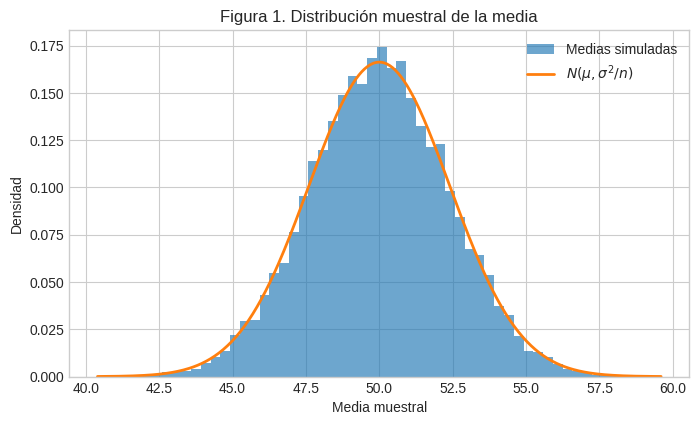

In [2]:
mu, sigma, n, repeticiones = 50, 12, 25, 20_000
medias = rng.normal(mu, sigma, size=(repeticiones, n)).mean(axis=1)
resumen_dm = pd.DataFrame({
    "Cantidad": ["Media de las medias", "DE empírica de las medias", "EE teórico"],
    "Valor": [medias.mean(), medias.std(ddof=1), sigma / np.sqrt(n)]
})
display(resumen_dm)

x = np.linspace(mu - 4*sigma/np.sqrt(n), mu + 4*sigma/np.sqrt(n), 400)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(medias, bins=55, density=True, alpha=0.65, label="Medias simuladas")
ax.plot(x, stats.norm.pdf(x, mu, sigma/np.sqrt(n)), lw=2,
        label=r"$N(\mu,\sigma^2/n)$")
ax.set(title="Figura 1. Distribución muestral de la media",
       xlabel="Media muestral", ylabel="Densidad")
ax.legend()
plt.show()


La desviación estándar empírica de las 20 000 medias se aproxima a \(\sigma/\sqrt n=2.4\). Cada observación individual tiene desviación 12, pero los promedios fluctúan menos.


## 5. Error estándar y propiedades de estimadores

El **error estándar** es la desviación estándar de la distribución muestral:

\[
\operatorname{EE}(\widehat\theta)=
\sqrt{\operatorname{Var}(\widehat\theta)}.
\]

No es el error cometido en una muestra particular. Para \(\bar X\), el EE es \(\sigma/\sqrt n\), o se estima con \(s/\sqrt n\).

### Insesgadez

\(\widehat\theta\) es insesgado si \(E(\widehat\theta)=\theta\). Su sesgo es
\(\operatorname{Sesgo}(\widehat\theta)=E(\widehat\theta)-\theta\).

### Consistencia

\(\widehat\theta_n\) es consistente si converge en probabilidad a \(\theta\) cuando \(n\to\infty\). Un estimador puede ser sesgado para cada \(n\) y aun ser consistente si el sesgo y la varianza desaparecen.

### Eficiencia

Entre estimadores comparables, insesgados y bajo el mismo modelo, se llama más eficiente al que tiene menor varianza. Si se admiten estimadores sesgados, conviene comparar el error cuadrático medio.

### Error cuadrático medio

\[
\operatorname{ECM}(\widehat\theta)
=E[(\widehat\theta-\theta)^2]
=\operatorname{Var}(\widehat\theta)+\operatorname{Sesgo}(\widehat\theta)^2.
\]

### Suficiencia

Un estadístico \(T\) es suficiente para \(\theta\) si, una vez conocido \(T\), el resto de la muestra no aporta información adicional sobre \(\theta\) dentro del modelo. En una muestra Bernoulli, \(T=\sum X_i\) registra el número total de éxitos; el orden de ceros y unos no agrega información sobre \(p\). Esta idea depende del modelo y no significa que el estadístico conserve toda información para cualquier pregunta.


### Ejemplo analítico: dos estimadores de \(\sigma^2\)

Sea una muestra i.i.d. con varianza \(\sigma^2\). Defina

\[
\widetilde S^2=\frac1n\sum_{i=1}^n(X_i-\bar X)^2,\qquad
S^2=\frac1{n-1}\sum_{i=1}^n(X_i-\bar X)^2.
\]

Como
\[
E\left[\sum_{i=1}^n(X_i-\bar X)^2\right]=(n-1)\sigma^2,
\]
se obtiene
\[
E(\widetilde S^2)=\frac{n-1}{n}\sigma^2,\qquad E(S^2)=\sigma^2.
\]

Por tanto, \(\widetilde S^2\) tiene sesgo \(-\sigma^2/n\), mientras que \(S^2\) es insesgado. Esto no basta para declarar un ganador: compararemos también el ECM mediante simulación.


,n,Estimador,Promedio,Sesgo,Varianza,ECM
0,5,Divisor n,12.7571,-3.2429,79.6941,90.2050
1,5,Divisor n-1,15.9464,-0.0536,124.5220,124.5165
2,10,Divisor n,14.4169,-1.5831,47.4441,49.9472
3,10,Divisor n-1,16.0188,0.0188,58.5730,58.5695
4,30,Divisor n,15.4594,-0.5406,16.6224,16.9135
5,30,Divisor n-1,15.9925,-0.0075,17.7885,17.7874
6,100,Divisor n,15.8087,-0.1913,5.0720,5.1082
7,100,Divisor n-1,15.9684,-0.0316,5.1750,5.1756
8,500,Divisor n,15.9558,-0.0442,1.0259,1.0278
9,500,Divisor n-1,15.9878,-0.0122,1.0300,1.0301


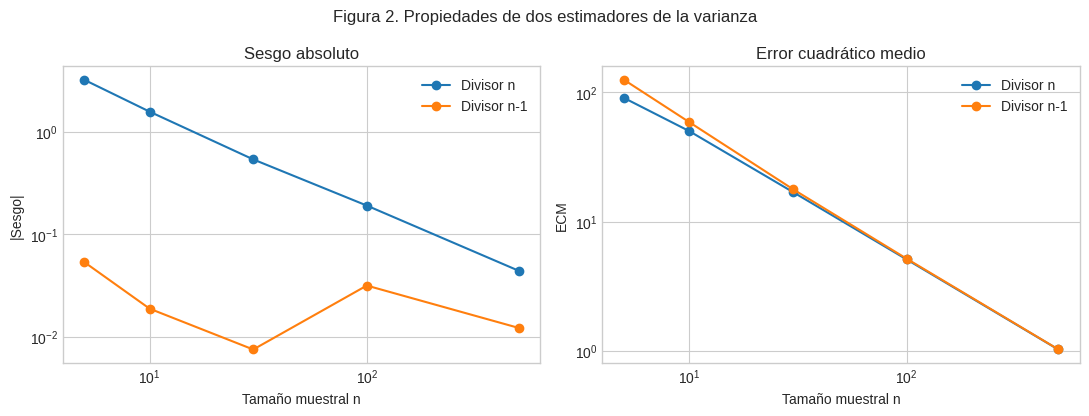

In [3]:
sigma2 = 16
ns = [5, 10, 30, 100, 500]
R = 15_000
filas = []
for n_i in ns:
    muestras = rng.normal(0, np.sqrt(sigma2), size=(R, n_i))
    v_n = muestras.var(axis=1, ddof=0)
    v_n1 = muestras.var(axis=1, ddof=1)
    for nombre, estimaciones in [("Divisor n", v_n), ("Divisor n-1", v_n1)]:
        filas.append({
            "n": n_i,
            "Estimador": nombre,
            "Promedio": estimaciones.mean(),
            "Sesgo": estimaciones.mean() - sigma2,
            "Varianza": estimaciones.var(ddof=1),
            "ECM": np.mean((estimaciones - sigma2)**2)
        })
propiedades = pd.DataFrame(filas)
display(propiedades)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for nombre, grupo in propiedades.groupby("Estimador"):
    axes[0].plot(grupo["n"], abs(grupo["Sesgo"]), marker="o", label=nombre)
    axes[1].plot(grupo["n"], grupo["ECM"], marker="o", label=nombre)
for ax, titulo, ylab in zip(
    axes, ["Sesgo absoluto", "Error cuadrático medio"], ["|Sesgo|", "ECM"]
):
    ax.set(xlabel="Tamaño muestral n", ylabel=ylab, title=titulo)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
fig.suptitle("Figura 2. Propiedades de dos estimadores de la varianza")
fig.tight_layout()
plt.show()


La simulación confirma tres ideas distintas: el divisor \(n-1\) corrige el sesgo; ambos estimadores se concentran alrededor de \(\sigma^2\) al crecer \(n\), lo que ilustra consistencia; y el criterio ECM puede favorecer al estimador sesgado en algunos tamaños porque incorpora simultáneamente varianza y sesgo.

**Error frecuente:** usar “insesgado”, “consistente” y “eficiente” como sinónimos. Son propiedades diferentes.


## 6. Método de momentos

Si el modelo tiene \(k\) parámetros, el método iguala \(k\) momentos poblacionales con sus análogos muestrales:

\[
E_\theta(X^j)=\frac1n\sum_{i=1}^n X_i^j,\qquad j=1,\ldots,k.
\]

### Ejemplo: distribución exponencial parametrizada por tasa

Sea \(X_i\sim\operatorname{Exp}(\lambda)\), con densidad
\[
f(x;\lambda)=\lambda e^{-\lambda x},\quad x\ge0,\ \lambda>0.
\]
Como \(E(X)=1/\lambda\), al igualar \(1/\lambda=\bar X\) resulta
\[
\widehat\lambda_{\text{MM}}=\frac1{\bar X}.
\]

El parámetro es la **tasa** por minuto; su inverso es el tiempo medio. Es esencial declarar esta parametrización, pues algunos textos y programas usan “escala” \(1/\lambda\).


In [4]:
retardos = np.array(
    [525, 719, 2880, 150, 30, 251, 45, 858, 15, 47,
     90, 56, 68, 6, 189, 180, 60, 60, 294, 747]
)
x_barra_ret = retardos.mean()
lambda_mm = 1 / x_barra_ret
pd.DataFrame({
    "Cantidad": ["n", "Media muestral (min)", "Tasa estimada (por min)",
                 "Tiempo medio estimado (min)"],
    "Valor": [retardos.size, x_barra_ret, lambda_mm, 1/lambda_mm]
})


,Cantidad,Valor
0,n,20.0000
1,Media muestral (min),363.5000
2,Tasa estimada (por min),0.0028
3,Tiempo medio estimado (min),363.5000


La muestra aporta los tiempos individuales, que se resumen mediante \(\bar x=363.5\) minutos. Bajo el modelo exponencial con tasa constante, la tasa estimada es \(0.002751\) por minuto. Una tasa no se interpreta como minutos: \(1/\widehat\lambda=363.5\) es el tiempo medio estimado.


## 7. Máxima verosimilitud

### Probabilidad frente a verosimilitud

En \(f(x;\theta)\), la **probabilidad** trata \(\theta\) como fijo y \(x\) como variable. Tras observar \(x\), la **verosimilitud** trata los datos como fijos y compara distintos valores posibles de \(\theta\):

\[
L(\theta;x_1,\ldots,x_n)=\prod_{i=1}^{n} f(x_i;\theta).
\]

La verosimilitud no es, en general, una distribución de probabilidad sobre \(\theta\) y no tiene que integrar uno respecto del parámetro.

### Log-verosimilitud y ejemplo Bernoulli

Para \(X_i\sim\operatorname{Bernoulli}(p)\),
\[
L(p)=p^{\sum x_i}(1-p)^{n-\sum x_i},
\]
\[
\ell(p)=\log L(p)=
\left(\sum x_i\right)\log p+
\left(n-\sum x_i\right)\log(1-p).
\]

Derivando,
\[
\ell'(p)=\frac{\sum x_i}{p}
-\frac{n-\sum x_i}{1-p}.
\]
Si \(0<\sum x_i<n\), resolver \(\ell'(p)=0\) da
\[
\widehat p_{\text{MV}}=\frac{\sum x_i}{n}=\bar X.
\]
Además, \(\ell''(p)<0\) en \(0<p<1\), por lo que el punto crítico es máximo. Si todos los resultados son 0 o 1, el máximo se alcanza en la frontera \(p=0\) o \(p=1\).

Trabajar con \(\ell\) evita productos numéricamente diminutos y convierte productos en sumas sin cambiar el punto de máximo porque el logaritmo es creciente.


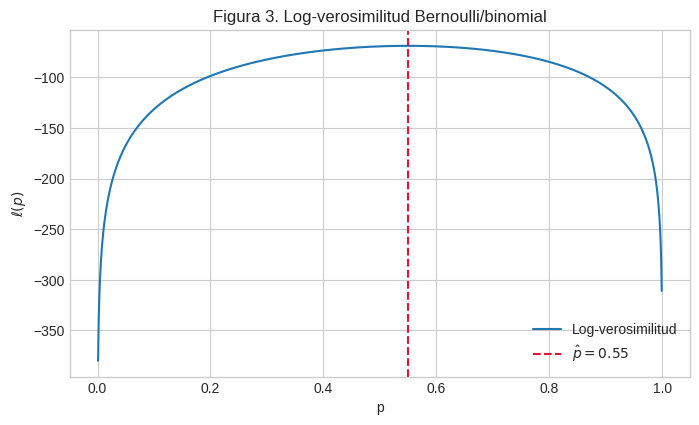

Cálculo manual: p_hat = 55/100 = 0.5500
Comprobación por búsqueda numérica: 0.5504


In [5]:
n, exitos = 100, 55
p_grid = np.linspace(0.001, 0.999, 1000)
logL = exitos*np.log(p_grid) + (n-exitos)*np.log(1-p_grid)
p_grid_max = p_grid[np.argmax(logL)]
p_hat = exitos / n

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p_grid, logL, label="Log-verosimilitud")
ax.axvline(p_hat, color="crimson", ls="--",
           label=fr"$\hat p={p_hat:.2f}$")
ax.set(title="Figura 3. Log-verosimilitud Bernoulli/binomial",
       xlabel="p", ylabel=r"$\ell(p)$")
ax.legend()
plt.show()

print(f"Cálculo manual: p_hat = {exitos}/{n} = {p_hat:.4f}")
print(f"Comprobación por búsqueda numérica: {p_grid_max:.4f}")


El parámetro buscado es la probabilidad poblacional de éxito. La muestra aporta 55 éxitos en 100 ensayos independientes con probabilidad común. Tanto la derivación como la comprobación numérica ubican el máximo cerca de \(0.55\).

**Errores frecuentes:** confundir \(L(p)\) con \(P(p\mid x)\), omitir el soporte, ignorar soluciones de frontera o afirmar que el máximo garantiza un buen ajuste del modelo.


### Momentos y máxima verosimilitud para la exponencial

Para \(X_i\sim\operatorname{Exp}(\lambda)\),
\[
\ell(\lambda)=n\log\lambda-\lambda\sum x_i,\qquad
\ell'(\lambda)=\frac n\lambda-\sum x_i.
\]
Por tanto,
\[
\widehat\lambda_{\text{MV}}=\frac{n}{\sum x_i}=\frac1{\bar X},
\]
que coincide aquí con el método de momentos. La coincidencia no es universal.


In [6]:
lambda_mle = retardos.size / retardos.sum()
resultado_metodos = pd.DataFrame({
    "Método": ["Momentos", "Máxima verosimilitud"],
    "Estimación de lambda": [lambda_mm, lambda_mle]
})
display(resultado_metodos)


,Método,Estimación de lambda
0,Momentos,0.0028
1,Máxima verosimilitud,0.0028


## 8. Distribuciones chi-cuadrada, t y F

Estas distribuciones se construyen a partir de normales estándar independientes:

1. Si \(Z_1,\ldots,Z_\nu\overset{iid}{\sim}N(0,1)\), entonces
   \[
   U=\sum_{j=1}^{\nu}Z_j^2\sim\chi^2_\nu.
   \]
2. Si \(Z\sim N(0,1)\), \(U\sim\chi^2_\nu\) e independientes,
   \[
   T=\frac{Z}{\sqrt{U/\nu}}\sim t_\nu.
   \]
3. Si \(U_1\sim\chi^2_{\nu_1}\), \(U_2\sim\chi^2_{\nu_2}\) e independientes,
   \[
   F=\frac{U_1/\nu_1}{U_2/\nu_2}\sim F_{\nu_1,\nu_2}.
   \]

La \(\chi^2\) es positiva y aparece en inferencia sobre varianzas normales; \(t\) es simétrica y tiene colas más pesadas que la normal; \(F\) es positiva y se relaciona con cocientes de varianzas. Los grados de libertad forman parte de cada distribución.


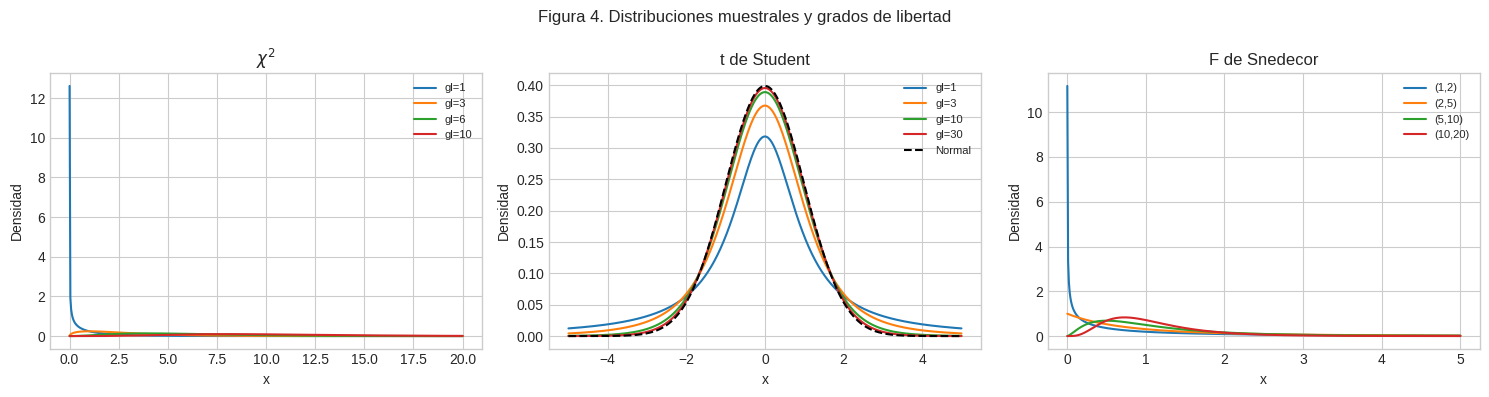

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x_chi = np.linspace(0.001, 20, 500)
for gl in [1, 3, 6, 10]:
    axes[0].plot(x_chi, stats.chi2.pdf(x_chi, gl), label=f"gl={gl}")
axes[0].set(title=r"$\chi^2$", xlabel="x", ylabel="Densidad")

x_t = np.linspace(-5, 5, 500)
for gl in [1, 3, 10, 30]:
    axes[1].plot(x_t, stats.t.pdf(x_t, gl), label=f"gl={gl}")
axes[1].plot(x_t, stats.norm.pdf(x_t), color="black", ls="--", label="Normal")
axes[1].set(title="t de Student", xlabel="x", ylabel="Densidad")

x_f = np.linspace(0.001, 5, 500)
for gl1, gl2 in [(1, 2), (2, 5), (5, 10), (10, 20)]:
    axes[2].plot(x_f, stats.f.pdf(x_f, gl1, gl2),
                 label=f"({gl1},{gl2})")
axes[2].set(title="F de Snedecor", xlabel="x", ylabel="Densidad")

for ax in axes:
    ax.legend(fontsize=8)
fig.suptitle("Figura 4. Distribuciones muestrales y grados de libertad")
fig.tight_layout()
plt.show()


### Comprobación de las construcciones

La simulación siguiente genera las variables mediante sus definiciones, no con `scipy.stats`, y compara cuantiles empíricos con cuantiles teóricos.


In [8]:
R = 100_000
nu, nu1, nu2 = 8, 5, 12
u = np.sum(rng.standard_normal((R, nu))**2, axis=1)
z = rng.standard_normal(R)
t_construida = z / np.sqrt(u / nu)
u1 = np.sum(rng.standard_normal((R, nu1))**2, axis=1)
u2 = np.sum(rng.standard_normal((R, nu2))**2, axis=1)
f_construida = (u1 / nu1) / (u2 / nu2)

q = [0.05, 0.5, 0.95]
comparacion = pd.DataFrame({
    "Distribución": np.repeat(["Chi-cuadrada(8)", "t(8)", "F(5,12)"], 3),
    "Cuantil": q * 3,
    "Empírico": np.r_[np.quantile(u, q), np.quantile(t_construida, q),
                      np.quantile(f_construida, q)],
    "Teórico": np.r_[stats.chi2.ppf(q, nu), stats.t.ppf(q, nu),
                     stats.f.ppf(q, nu1, nu2)]
})
display(comparacion)


,Distribución,Cuantil,Empírico,Teórico
0,Chi-cuadrada(8),0.05,2.7315,2.7326e+00
1,Chi-cuadrada(8),0.50,7.3477,7.3441e+00
2,Chi-cuadrada(8),0.95,15.5035,1.5507e+01
3,t(8),0.05,-1.8635,-1.8595e+00
4,t(8),0.50,-0.0045,6.8481e-17
5,t(8),0.95,1.8549,1.8595e+00
6,"F(5,12)",0.05,0.2113,2.1378e-01
7,"F(5,12)",0.50,0.9181,9.2124e-01
8,"F(5,12)",0.95,3.0934,3.1059e+00


## 9. Estimación por intervalos

Un intervalo aleatorio \([L(X),U(X)]\) tiene nivel de confianza \(1-\alpha\) si
\[
P_\theta\{L(X)\le\theta\le U(X)\}=1-\alpha
\]
para los valores de \(\theta\) cubiertos por la derivación.

La **cobertura** describe el porcentaje de intervalos que contienen al parámetro en repeticiones del procedimiento. Después de observar una muestra, los extremos son fijos y el parámetro frecuentista también: no se interpreta como una probabilidad de \(1-\alpha\) sobre ese parámetro.

La estructura usual es
\[
\text{estimador}\ \pm\ \text{valor crítico}\times\text{error estándar}.
\]
Procede de despejar \(\theta\) en una cantidad pivotal cuya distribución no depende de parámetros desconocidos.


### 9.1 Media normal con varianza conocida

**Parámetro:** \(\mu\).  
**Supuestos:** muestra aleatoria i.i.d. de \(N(\mu,\sigma^2)\), con \(\sigma\) conocida.  
**Pivote:**
\[
Z=\frac{\bar X-\mu}{\sigma/\sqrt n}\sim N(0,1).
\]
Al invertir \(-z_{1-\alpha/2}\le Z\le z_{1-\alpha/2}\):
\[
\bar X\pm z_{1-\alpha/2}\frac{\sigma}{\sqrt n}.
\]

**Ejemplo manual.** Para \(n=49\), \(\bar x=22.60\), \(\sigma=2.5\) y 95%,
\[
\operatorname{EE}=2.5/\sqrt{49}=0.3571,\qquad
ME=1.96(0.3571)\approx0.70,
\]
por lo que el intervalo es aproximadamente \((21.90,23.30)\).


In [9]:
n, x_barra, sigma, confianza = 49, 22.60, 2.5, 0.95
ee = sigma / np.sqrt(n)
z_crit = stats.norm.ppf(1 - (1-confianza)/2)
ic_z = ic_media_sigma_conocida(x_barra, sigma, n, confianza)
pd.DataFrame({
    "n": [n], "Media": [x_barra], "EE": [ee], "z crítico": [z_crit],
    "Límite inferior": [ic_z[0]], "Límite superior": [ic_z[1]]
})


,n,Media,EE,z crítico,Límite inferior,Límite superior
0,49,22.6,0.3571,1.96,21.9,23.3


Con 95% de confianza, el procedimiento produce el intervalo \((21.90,23.30)\) para el consumo medio poblacional. No se afirma que 95% de los clientes consuman dentro de ese rango ni que \(\mu\) tenga 95% de probabilidad de estar allí.


### 9.2 Media normal con varianza desconocida

**Parámetro:** \(\mu\).  
**Supuestos:** muestra aleatoria i.i.d. de una población normal; \(\sigma\) desconocida.  
**Pivote:**
\[
T=\frac{\bar X-\mu}{S/\sqrt n}\sim t_{n-1}.
\]
Por ello,
\[
\bar X\pm t_{1-\alpha/2,n-1}\frac{s}{\sqrt n}.
\]

La distribución \(t\), no una regla automática basada sólo en “\(n\le30\)”, surge al estimar \(\sigma\) con \(S\) bajo normalidad. Para poblaciones no normales, la robustez depende del tamaño, la asimetría y los valores atípicos.


In [10]:
datos_t = np.array([45, 55, 67, 68, 45, 79, 98, 87, 84, 82])
n = datos_t.size
x_barra = datos_t.mean()
s = datos_t.std(ddof=1)
confianza = 0.99
t_crit = stats.t.ppf(1-(1-confianza)/2, n-1)
ee = s/np.sqrt(n)
ic_t = ic_media_sigma_desconocida(datos_t, confianza)
pd.DataFrame({
    "n": [n], "Media": [x_barra], "s": [s], "EE": [ee],
    "t crítico": [t_crit], "Límite inferior": [ic_t[0]],
    "Límite superior": [ic_t[1]]
})


,n,Media,s,EE,t crítico,Límite inferior,Límite superior
0,10,71.0,18.172,5.7465,3.2498,52.3248,89.6752


El cálculo manual sigue \( \bar x\pm t_{0.995,9}s/\sqrt{10}\). El intervalo es amplio porque el nivel es 99%, la muestra es pequeña y la variabilidad muestral no es despreciable.

**Error frecuente:** sustituir \(s\) en el error estándar y conservar el valor crítico normal sin justificar una aproximación.


### 9.3 Intervalo aproximado para una proporción

Si \(X\sim\operatorname{Bin}(n,p)\), el estimador es \(\hat p=X/n\). La aproximación normal de Wald usa
\[
\hat p\pm z_{1-\alpha/2}
\sqrt{\frac{\hat p(1-\hat p)}{n}}.
\]

Requiere independencia y una aproximación normal razonable; una regla práctica es que \(n\hat p\) y \(n(1-\hat p)\) no sean pequeños. Cerca de 0 o 1, o con muestras pequeñas, Wald puede cubrir mal e incluso salir de \([0,1]\); se prefieren alternativas como Wilson o intervalos exactos según el objetivo.


In [11]:
n, exitos, confianza = 200, 118, 0.95
p_hat = exitos/n
ic_p = ic_proporcion_wald(exitos, n, confianza)
z = stats.norm.ppf(0.975)
ee_p = np.sqrt(p_hat*(1-p_hat)/n)
pd.DataFrame({
    "Éxitos": [exitos], "n": [n], "p_hat": [p_hat], "EE": [ee_p],
    "z crítico": [z], "Límite inferior": [ic_p[0]],
    "Límite superior": [ic_p[1]]
})


,Éxitos,n,p_hat,EE,z crítico,Límite inferior,Límite superior
0,118,200,0.59,0.0348,1.96,0.5218,0.6582


La muestra aporta 118 éxitos de 200, de modo que \(\hat p=0.59\). El intervalo aproximado es \((0.522,0.658)\). La interpretación se refiere a la proporción poblacional, no a la probabilidad de cada observación ya registrada.


### 9.4 Complemento: intervalo para la varianza

Para una muestra i.i.d. de una población **normal**,
\[
\frac{(n-1)S^2}{\sigma^2}\sim\chi^2_{n-1}.
\]
Al invertir los cuantiles:
\[
\left[
\frac{(n-1)s^2}{\chi^2_{1-\alpha/2,n-1}},
\frac{(n-1)s^2}{\chi^2_{\alpha/2,n-1}}
\right].
\]
El intervalo es asimétrico y depende especialmente de la normalidad poblacional.


In [12]:
datos_var = rng.normal(1750, 315.8, size=100)
ic_var = ic_varianza_normal(datos_var, 0.90)
pd.DataFrame({
    "n": [datos_var.size], "s²": [datos_var.var(ddof=1)],
    "Límite inferior": [ic_var[0]], "Límite superior": [ic_var[1]]
})


,n,s²,Límite inferior,Límite superior
0,100,80128.3182,64375.6482,102960.171


## 10. Efectos de \(n\) y del nivel de confianza

Con \(\sigma\) fija, la amplitud del intervalo \(z\) para una media es
\[
A=2z_{1-\alpha/2}\frac{\sigma}{\sqrt n}.
\]
Por tanto, multiplicar \(n\) por cuatro reduce la amplitud a la mitad. Aumentar el nivel de confianza eleva el valor crítico y ensancha el intervalo: mayor cobertura exige menor precisión, manteniendo lo demás constante.


,90%,95%,99%
n,,,
10,10.4030,12.3959,16.2910
20,7.3560,8.7652,11.5195
30,6.0062,7.1568,9.4056
50,4.6523,5.5436,7.2855
100,3.2897,3.9199,5.1517
200,2.3262,2.7718,3.6428
500,1.4712,1.7530,2.3039


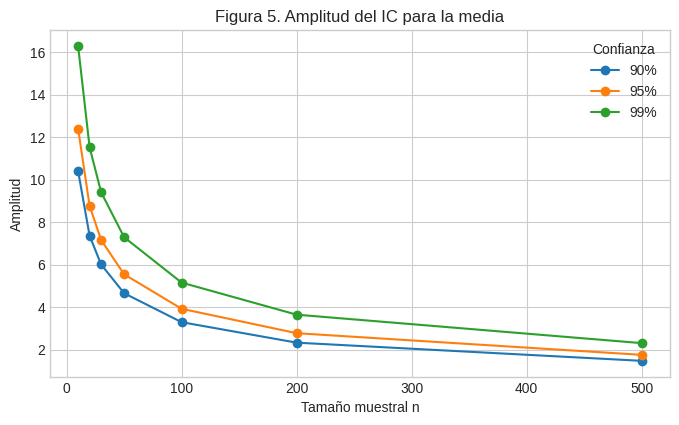

In [13]:
sigma = 10
ns = np.array([10, 20, 30, 50, 100, 200, 500])
confianzas = [0.90, 0.95, 0.99]
anchos = pd.DataFrame({
    f"{int(c*100)}%": 2*stats.norm.ppf(1-(1-c)/2)*sigma/np.sqrt(ns)
    for c in confianzas
}, index=ns)
anchos.index.name = "n"
display(anchos)

fig, ax = plt.subplots(figsize=(8, 4.5))
for col in anchos:
    ax.plot(anchos.index, anchos[col], marker="o", label=col)
ax.set(title="Figura 5. Amplitud del IC para la media",
       xlabel="Tamaño muestral n", ylabel="Amplitud")
ax.legend(title="Confianza")
plt.show()


La tabla y la figura muestran efectos separados: con confianza fija, la amplitud cae como \(1/\sqrt n\); con \(n\) fijo, 99% produce intervalos más anchos que 95% y 90%.


## 11. Simulación de cobertura

Fijaremos \(\mu=100\), \(\sigma=15\) y repetiremos el muestreo. En cada repetición se calcula un intervalo de 95% para \(\mu\) con \(\sigma\) desconocida. La cobertura empírica es la proporción de intervalos que contienen al mismo \(\mu\) fijo.


In [14]:
mu, sigma, n, R, confianza = 100, 15, 20, 10_000, 0.95
muestras = rng.normal(mu, sigma, size=(R, n))
medias = muestras.mean(axis=1)
s = muestras.std(axis=1, ddof=1)
tcrit = stats.t.ppf(1-(1-confianza)/2, n-1)
margenes = tcrit*s/np.sqrt(n)
li, ls = medias-margenes, medias+margenes
cubre = (li <= mu) & (mu <= ls)

pd.DataFrame({
    "Repeticiones": [R],
    "Cobertura nominal": [confianza],
    "Cobertura empírica": [cubre.mean()],
    "Error Monte Carlo aprox.": [np.sqrt(cubre.mean()*(1-cubre.mean())/R)]
})


,Repeticiones,Cobertura nominal,Cobertura empírica,Error Monte Carlo aprox.
0,10000,0.95,0.9496,0.0022


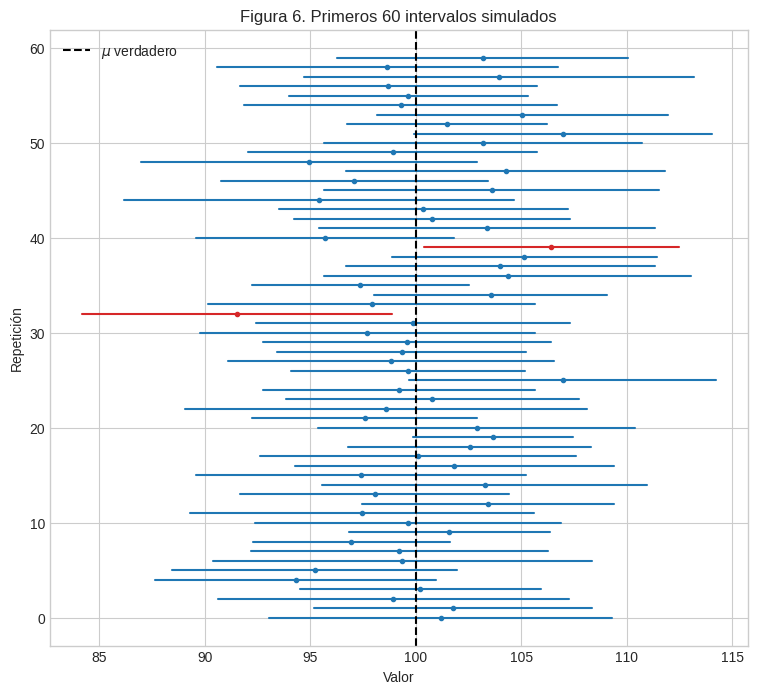

In [15]:
k = 60
y = np.arange(k)
colores = np.where(cubre[:k], "tab:blue", "tab:red")
fig, ax = plt.subplots(figsize=(9, 8))
for i in range(k):
    ax.plot([li[i], ls[i]], [y[i], y[i]], color=colores[i], lw=1.5)
    ax.plot(medias[i], y[i], "o", color=colores[i], ms=3)
ax.axvline(mu, color="black", ls="--", label=r"$\mu$ verdadero")
ax.set(title="Figura 6. Primeros 60 intervalos simulados",
       xlabel="Valor", ylabel="Repetición")
ax.legend()
plt.show()


Los intervalos azules cubren \(\mu\) y los rojos no. La cobertura empírica debe quedar cerca de 0.95, con variación Monte Carlo. Esto explica el nivel de confianza sin asignar una distribución de probabilidad al parámetro fijo.


## 12. Laboratorio integrador

Una planta controla el peso de paquetes cuyo proceso, durante un periodo estable, puede modelarse aproximadamente como normal. Se seleccionan 24 paquetes de manera independiente. El objetivo es estimar la media y la varianza del peso; además se estudiará la estabilidad de la estimación mediante bootstrap.

**Supuestos a revisar:** independencia derivada del diseño, medición en escala continua, proceso sin cambios durante el muestreo y normalidad aproximada para los procedimientos exactos \(t\) y \(\chi^2\).


,n,Media (g),Mediana (g),s (g),Mínimo (g),Máximo (g)
0,24,500.5333,500.5,2.0207,496.8,504.0


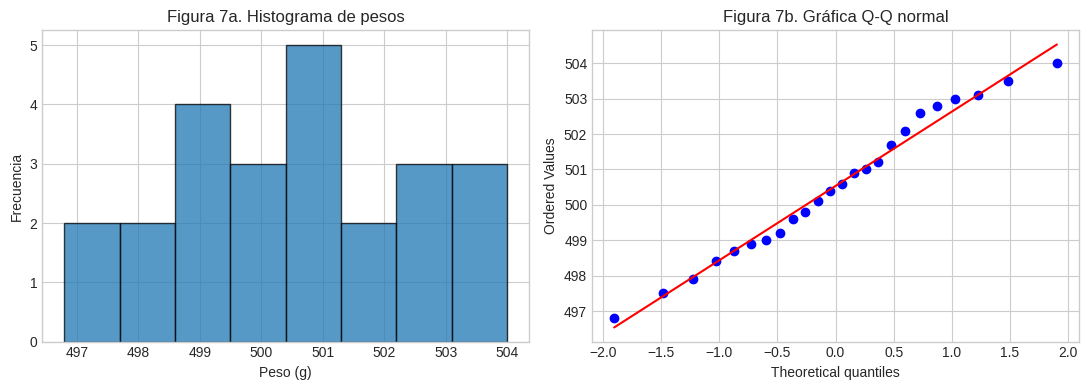

In [16]:
pesos = np.array([
    501.2, 498.7, 503.1, 500.4, 497.9, 502.6, 499.8, 504.0,
    500.9, 496.8, 501.7, 499.2, 502.1, 500.1, 498.4, 503.5,
    499.6, 501.0, 497.5, 502.8, 500.6, 499.0, 503.0, 498.9
])
n = pesos.size
resumen = pd.DataFrame({
    "n": [n],
    "Media (g)": [pesos.mean()],
    "Mediana (g)": [np.median(pesos)],
    "s (g)": [pesos.std(ddof=1)],
    "Mínimo (g)": [pesos.min()],
    "Máximo (g)": [pesos.max()]
})
display(resumen)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pesos, bins=8, edgecolor="black", alpha=0.75)
axes[0].set(title="Figura 7a. Histograma de pesos",
            xlabel="Peso (g)", ylabel="Frecuencia")
stats.probplot(pesos, dist="norm", plot=axes[1])
axes[1].set_title("Figura 7b. Gráfica Q-Q normal")
fig.tight_layout()
plt.show()


La muestra aporta el centro, la dispersión y una evaluación gráfica limitada de la forma. Con \(n=24\), una gráfica Q-Q ayuda a detectar desviaciones grandes, pero no demuestra normalidad ni sustituye el conocimiento del proceso.

### Cálculo manual

Para la media se utiliza
\[
\bar x\pm t_{0.975,23}\frac{s}{\sqrt{24}}.
\]
Para la varianza se utiliza el pivote \((n-1)S^2/\sigma^2\). El código siguiente desglosa los componentes y los contrasta con las funciones reutilizables.


In [17]:
confianza = 0.95
x_barra = pesos.mean()
s = pesos.std(ddof=1)
ee = s/np.sqrt(n)
tcrit = stats.t.ppf(0.975, n-1)
margen = tcrit*ee
ic_media = (x_barra-margen, x_barra+margen)
ic_media_funcion = ic_media_sigma_desconocida(pesos, confianza)
ic_s2 = ic_varianza_normal(pesos, confianza)

tabla_lab = pd.DataFrame({
    "Procedimiento": ["IC 95% para media", "IC 95% para varianza"],
    "Estimación puntual": [x_barra, s**2],
    "Límite inferior": [ic_media[0], ic_s2[0]],
    "Límite superior": [ic_media[1], ic_s2[1]]
})
display(pd.DataFrame({
    "Componente": ["Media", "s", "EE", "t crítico", "Margen"],
    "Valor": [x_barra, s, ee, tcrit, margen]
}))
display(tabla_lab)
print("Coincidencia cálculo manual/función:",
      np.allclose(ic_media, ic_media_funcion))


,Componente,Valor
0,Media,500.5333
1,s,2.0207
2,EE,0.4125
3,t crítico,2.0687
4,Margen,0.8533


,Procedimiento,Estimación puntual,Límite inferior,Límite superior
0,IC 95% para media,500.5333,499.6801,501.3866
1,IC 95% para varianza,4.0832,2.4665,8.0346


Coincidencia cálculo manual/función: True


El intervalo para la media estima el peso medio del proceso, no el rango de pesos individuales. El intervalo para la varianza cuantifica la incertidumbre sobre la dispersión poblacional y es asimétrico. Ambos resultados dependen del muestreo y del supuesto de normalidad; si hay dependencia temporal o cambios de proceso, las fórmulas pueden subestimar la incertidumbre.

### Estabilidad mediante bootstrap

El bootstrap re-muestrea con reemplazo la muestra observada para aproximar la distribución del estimador. Aquí se usa como diagnóstico didáctico de la media, no como sustituto automático del diseño de muestreo.


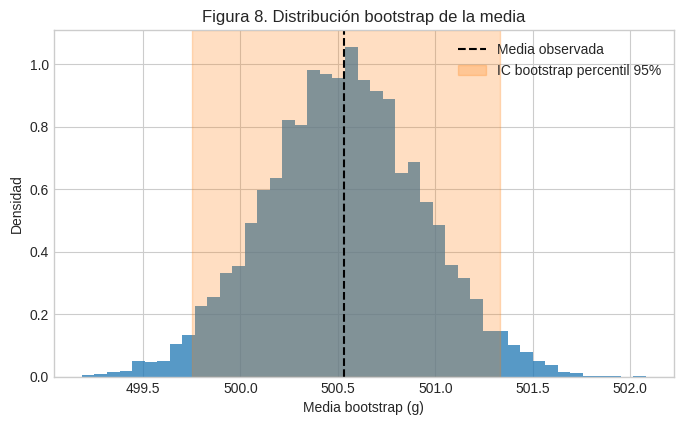

,Método,Límite inferior,Límite superior
0,t de Student,499.6801,501.3866
1,Bootstrap percentil,499.7500,501.3334


In [18]:
B = 10_000
indices = rng.integers(0, n, size=(B, n))
medias_boot = pesos[indices].mean(axis=1)
ic_boot_percentil = np.quantile(medias_boot, [0.025, 0.975])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(medias_boot, bins=45, density=True, alpha=0.75)
ax.axvline(x_barra, color="black", ls="--", label="Media observada")
ax.axvspan(*ic_boot_percentil, color="tab:orange", alpha=0.25,
           label="IC bootstrap percentil 95%")
ax.set(title="Figura 8. Distribución bootstrap de la media",
       xlabel="Media bootstrap (g)", ylabel="Densidad")
ax.legend()
plt.show()

pd.DataFrame({
    "Método": ["t de Student", "Bootstrap percentil"],
    "Límite inferior": [ic_media[0], ic_boot_percentil[0]],
    "Límite superior": [ic_media[1], ic_boot_percentil[1]]
})


En esta muestra relativamente simétrica, ambos procedimientos producen resultados cercanos. Esa cercanía es evidencia descriptiva de estabilidad, no una prueba de que todos los supuestos sean verdaderos.

### Errores frecuentes del laboratorio

- Interpretar el IC de la media como intervalo para 95% de los paquetes.
- Usar `ddof=0` como si fuera la varianza muestral insesgada.
- Aplicar el IC \(\chi^2\) a datos fuertemente no normales sin advertencia.
- Confundir un intervalo estrecho con ausencia de sesgo de selección.
- Redondear durante los pasos intermedios y alterar los extremos.


## 13. Conclusiones

1. La inferencia invierte el sentido de la probabilidad: usa una muestra y un modelo para aprender sobre parámetros desconocidos.
2. Un estimador debe evaluarse con criterios explícitos. Insesgadez, consistencia, eficiencia, ECM y suficiencia describen aspectos distintos.
3. Momentos y máxima verosimilitud son reglas de construcción; pueden coincidir, como en la exponencial parametrizada por tasa, pero no necesariamente.
4. Las distribuciones \(\chi^2\), \(t\) y \(F\) surgen de combinaciones de normales y sustentan procedimientos inferenciales bajo condiciones concretas.
5. Un intervalo de confianza describe la cobertura de un procedimiento de muestreo repetido. Mayor \(n\) reduce la amplitud; mayor confianza la aumenta.
6. La simulación sirve para comprobar propiedades y revelar variabilidad, pero no repara muestras sesgadas ni supuestos inadecuados.


## 14. Bibliografía

### Bibliografía principal indicada para el proyecto

- Rincón, Luis. *Una introducción a la estadística inferencial*.
- Wackerly, Dennis D.; Mendenhall, William; Scheaffer, Richard L. *Estadística matemática con aplicaciones*.
- Mood, Alexander M.; Graybill, Franklin A.; Boes, Duane C. *Introduction to the Theory of Statistics*.
- Rincón, Luis. *Introducción a la probabilidad*.

